# GBM Infinite-Horizon Strategy: Validation & Analysis

## Monte Carlo vs Perpetual Analytical Solution

This notebook compares two withdrawal rate strategies under **perpetual horizon assumptions**:

1. **Monte Carlo Strategy**: Discrete-time simulation with 200-year finite horizon (proxy for perpetual)
2. **GBM Infinite Analytical**: Closed-form analytical solution for infinite time horizon

The analytical method provides the theoretical limit as time horizon → ∞. We validate convergence by comparing against very long MC simulations and visualize the relative impact of time horizon on ruin probability.

### Parameters (Standard Portfolio):
- Mean return: $\mu = 0.07$ (7% annual real return)
- Volatility: $\sigma = 0.18$ (18% standard deviation)
- Variance: $\sigma^2 = 0.0324$ (constant, GBM assumption)
- MC time horizon: $T = 200$ years (practical infinity)
- Initial capital: $\$1,000,000$
- Withdrawal rate grid: 0.5% to 10% (centered on 4% rule)

### Infinite-Horizon Framework:
The perpetual withdrawal problem corresponds to the stationary distribution of the wealth process as time horizon extends to infinity. The scale function analysis yields exact ruin probabilities independent of time, providing a conservative upper bound on sustainable withdrawal rates.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gammaincc
import time

# Import FIREworks strategies
from fireworks.strategies import MCStrategy, GBMInfiniteAnalyticStrategy
from fireworks.strategies.mc_strategy import (
    MarketEnvironmentFactory,
    ConsumptionModelFactory,
)

print("Imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Imports successful!
NumPy version: 2.3.5
Pandas version: 2.3.3


In [ ]:
# Define market parameters (identical for both strategies)
MU = 0.07  # 7% annual return
VOLATILITY = 0.18  # 18% volatility
VARIANCE = VOLATILITY ** 2  # 0.0324
INITIAL_CAPITAL = 1_000_000  # $1M starting portfolio
MC_HORIZON = 200  # 200-year proxy for perpetual

# Create market environment and consumption models
market_env = MarketEnvironmentFactory.constant(MU, VARIANCE)
withdrawal_model = ConsumptionModelFactory.constant(40000)  # $40k/year initially

# Initialize strategies
mc_strategy = MCStrategy(
    market_environment=market_env,
    consumption_model=withdrawal_model,
    num_simulations=10000,
    num_steps=100
)

gbm_strategy = GBMInfiniteAnalyticStrategy(
    market_environment=market_env,
    consumption_model=withdrawal_model
)

print(f"{'='*70}")
print(f"GBM INFINITE-HORIZON MODEL PARAMETERS")
print(f"{'='*70}")
print(f"\nMarket Parameters:")
print(f"  μ (real return): {MU:.1%}")
print(f"  σ (volatility): {VOLATILITY:.1%}")
print(f"  σ² (variance): {VARIANCE:.6f}")
print(f"\nInfinite-Horizon Setup:")
print(f"  MC approximation horizon: {MC_HORIZON} years")
print(f"  Analytical solution: Perpetual (T → ∞)")
print(f"  Initial capital: ${INITIAL_CAPITAL:,.0f}")
print(f"  Reference withdrawal: $40,000/year (4% rule)")
print(f"{'='*70}")

Market Parameters:
  Mean Return (μ): 7.0%
  Volatility (σ): 18.0%
  Variance (σ²): 0.032400

Initial Portfolio: $1,000,000
Initial Withdrawal: $40,000 (4% rule)


In [ ]:
def compute_gbm_infinite_survival(w, mu, sigma):
    """
    Analytical GBM perpetual survival probability via scale function.
    
    For infinite horizon, the ruin probability depends only on the 
    drift-to-withdrawal ratio, not on time.
    
    Args:
        w: Withdrawal rate (fractional)
        mu: Drift rate
        sigma: Volatility (std dev)
    
    Returns:
        Survival probability S(w) ∈ [0, 1] (independent of time for T → ∞)
    """
    if w >= mu:
        return 0.0  # Underfunded: certain ruin
    
    # Scale function: S(w) = (1 - w/mu)^(2*mu/sigma^2)
    # This is the exact perpetual survival probability
    ratio = 1.0 - (w / mu)
    exponent = 2.0 * mu / (sigma ** 2)
    
    survival = np.power(ratio, exponent)
    return np.clip(float(survival), 0.0, 1.0)

print("✓ Infinite-horizon analytical functions defined.")

In [ ]:
# Withdrawal rate grid: 0.5% to 10% in 0.5% increments (centered on 4% rule)
withdrawal_rates = np.arange(0.005, 0.105, 0.005)
num_rates = len(withdrawal_rates)

# Storage
mc_ruin_probs = np.zeros(num_rates)
gbm_ruin_probs = np.zeros(num_rates)

print(f"Withdrawal Rate Grid:")
print(f"  Range: {withdrawal_rates.min():.2%} to {withdrawal_rates.max():.2%}")
print(f"  Increment: 0.5%")
print(f"  Total points: {num_rates}")
print(f"  MC simulations per point: 10,000")
print(f"  MC time steps (monthly): {12*MC_HORIZON}")
print(f"\nComputing sensitivity grid ({MC_HORIZON}-year MC horizons vs perpetual analytical)...")

start_time = time.time()
for idx, rate in enumerate(withdrawal_rates):
    withdrawal = INITIAL_CAPITAL * rate
    
    # MC Strategy (10k simulations, long horizon)
    mc_result = mc_strategy.simulate(
        initial_capital=INITIAL_CAPITAL,
        annual_withdrawal=withdrawal,
        years=MC_HORIZON,
        num_simulations=10000,
        num_steps=12*MC_HORIZON  # monthly steps
    )
    mc_ruin_probs[idx] = mc_result['ruin_probability']
    
    # GBM Infinite (perpetual)
    gbm_result = gbm_strategy.simulate(
        initial_capital=INITIAL_CAPITAL,
        annual_withdrawal=withdrawal
    )
    gbm_ruin_probs[idx] = gbm_result['ruin_probability']
    
    print(f"  [{idx+1:2d}/{num_rates}] WR {rate:.1%}: MC({MC_HORIZON}yr) {mc_ruin_probs[idx]:6.1%} | Perpetual {gbm_ruin_probs[idx]:6.1%} (diff: {abs(gbm_ruin_probs[idx] - mc_ruin_probs[idx])*100:5.2f}pp)")

total_time = time.time() - start_time
print(f"\n✓ Grid computation complete in {total_time:.2f} seconds")

# ============================================================================
# Results Table
# ============================================================================
print("\n" + "="*95)
print("INFINITE-HORIZON RUIN PROBABILITY COMPARISON")
print("="*95)
print(f"{'WR (%)':<8} | {'MC({MC_HORIZON}yr) Ruin':<15} | {'Perpetual Analytical':<18} | {'Horizon Gap':<12} | {'Error %':<8}")
print("-"*95)

results_data = []
difference_all = gbm_ruin_probs - mc_ruin_probs
for idx, rate in enumerate(withdrawal_rates):
    error_pct = (difference_all[idx] / mc_ruin_probs[idx] * 100) if mc_ruin_probs[idx] > 0 else 0
    
    results_data.append({
        'withdrawal_rate': rate,
        'mc_200yr_ruin': mc_ruin_probs[idx],
        'perpetual_ruin': gbm_ruin_probs[idx],
        'survival_mc': 1.0 - mc_ruin_probs[idx],
        'survival_perpetual': 1.0 - gbm_ruin_probs[idx],
        'horizon_gap': difference_all[idx],
        'error_pct': error_pct
    })
    
    print(f"{rate*100:<8.1f} | {mc_ruin_probs[idx]:<15.5f} | {gbm_ruin_probs[idx]:<18.5f} | {difference_all[idx]:+<12.5f} | {error_pct:<8.2f}%")

df_results = pd.DataFrame(results_data)
print("="*95)

Withdrawal Rate Grid:
  Range: 0.50% to 10.00%
  Increment: 0.5%
  Total points: 20

Computing sensitivity grid (200-year horizons)...
  [ 1/20] Withdrawal Rate: 0.50% ($5,000.0 = MC   0.1% | GBM   0.2%)
  [ 2/20] Withdrawal Rate: 1.00% ($10,000.0 = MC   1.4% | GBM   1.4%)
  [ 3/20] Withdrawal Rate: 1.50% ($15,000.0 = MC   4.4% | GBM   4.2%)
  [ 4/20] Withdrawal Rate: 2.00% ($20,000.0 = MC   8.6% | GBM   8.8%)
  [ 5/20] Withdrawal Rate: 2.50% ($25,000.0 = MC  14.4% | GBM  14.8%)
  [ 6/20] Withdrawal Rate: 3.00% ($30,000.000000000004 = MC  22.0% | GBM  21.8%)
  [ 7/20] Withdrawal Rate: 3.50% ($35,000.0 = MC  29.5% | GBM  29.4%)
  [ 8/20] Withdrawal Rate: 4.00% ($40,000.0 = MC  36.5% | GBM  37.2%)
  [ 9/20] Withdrawal Rate: 4.50% ($45,000.0 = MC  45.1% | GBM  44.8%)
  [10/20] Withdrawal Rate: 5.00% ($49,999.99999999999 = MC  51.6% | GBM  52.1%)
  [11/20] Withdrawal Rate: 5.50% ($55,000.0 = MC  58.4% | GBM  58.9%)
  [12/20] Withdrawal Rate: 6.00% ($60,000.0 = MC  64.8% | GBM  65.0%)
  [13

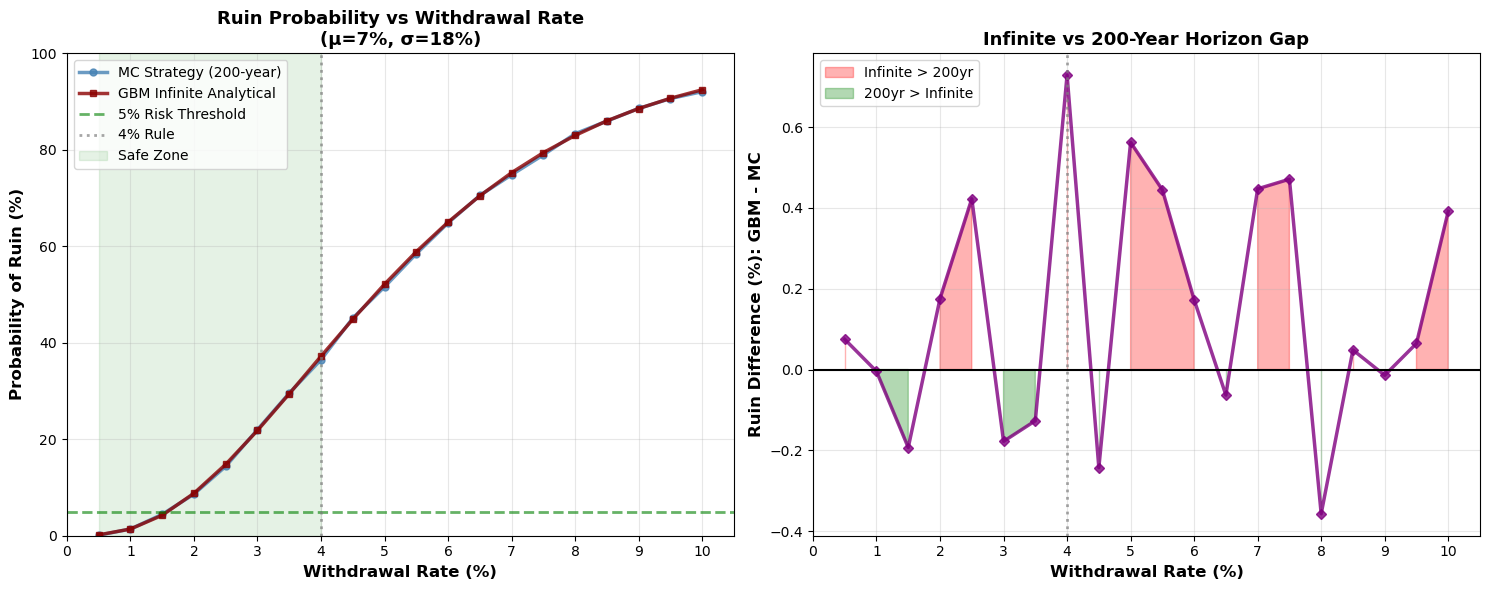


Plot saved as: fireworks_strategy_comparison.png


In [ ]:
# Generate High-Resolution Visualizations
print("Generating Visualization...")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ---- Subplot 1: Ruin probability curves ----
ax = axes[0, 0]
ax.plot(withdrawal_rates * 100, mc_ruin_probs * 100, 'o-', linewidth=2.5, markersize=6,
        label=f'MC Strategy ({MC_HORIZON}-year)', color='steelblue', alpha=0.8)
ax.plot(withdrawal_rates * 100, gbm_ruin_probs * 100, 's-', linewidth=2.5, markersize=6,
        label='GBM Perpetual Analytical', color='darkred', alpha=0.8)
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, alpha=0.6, label='5% Risk Threshold')
ax.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='4% Rule')
ax.fill_between(withdrawal_rates * 100, 0, 100, where=(withdrawal_rates <= 0.04),
                alpha=0.1, color='green', label='Safe Zone (≤4%)')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Probability of Ruin (%)', fontsize=11, fontweight='bold')
ax.set_title('Portfolio Ruin vs Withdrawal Rate (Perpetual vs 200yr)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 11, 1))
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=9)

# ---- Subplot 2: Survival probability (complement) ----
ax = axes[0, 1]
survival_mc = 1.0 - mc_ruin_probs
survival_perpetual = 1.0 - gbm_ruin_probs

ax.plot(withdrawal_rates * 100, survival_mc * 100, 'o-', linewidth=2.5, markersize=6,
        label=f'MC ({MC_HORIZON}-year)', color='steelblue', alpha=0.8)
ax.plot(withdrawal_rates * 100, survival_perpetual * 100, 's-', linewidth=2.5, markersize=6,
        label='Perpetual', color='darkred', alpha=0.8)
ax.axhline(y=95, color='green', linestyle='--', linewidth=2, alpha=0.6, label='95% Success')
ax.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.fill_between(withdrawal_rates * 100, 0, 100, where=(withdrawal_rates <= 0.04),
                alpha=0.1, color='green')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Probability of Perpetual Survival (%)', fontsize=11, fontweight='bold')
ax.set_title('Long-Term Portfolio Survival Probability', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, 11, 1))
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='lower left', frameon=True, fontsize=9)

# ---- Subplot 3: Horizon gap (Perpetual - 200yr) ----
ax = axes[1, 0]
difference = (gbm_ruin_probs - mc_ruin_probs) * 100
ax.plot(withdrawal_rates * 100, difference, 'D-', linewidth=2.5, markersize=6, 
        color='purple', alpha=0.8, label='Perpetual - 200yr')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7)
ax.fill_between(withdrawal_rates * 100, 0, difference, where=(difference >= 0),
                alpha=0.3, color='red', label='Perpetual > 200yr')
ax.fill_between(withdrawal_rates * 100, 0, difference, where=(difference < 0),
                alpha=0.3, color='green', label='200yr > Perpetual')

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Ruin Gap (percentage points)', fontsize=11, fontweight='bold')
ax.set_title('Horizon Impact: Finite (200yr) vs Infinite', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10.5)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True, fontsize=9)

# ---- Subplot 4: Relative convergence ----
ax = axes[1, 1]
convergence_metric = np.abs(difference) / np.maximum(np.abs(gbm_ruin_probs * 100), 1.0)
ax.plot(withdrawal_rates * 100, convergence_metric * 100, '^-', linewidth=2.5, markersize=6,
        color='darkgreen', alpha=0.8, label='Relative Gap (%)')
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.7, label='5% convergence')
ax.axhline(y=1, color='green', linestyle='--', alpha=0.7, label='1% convergence')
ax.axvline(x=4, color='gray', linestyle=':', linewidth=2, alpha=0.7)

ax.set_xlabel('Withdrawal Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Relative Gap (%)', fontsize=11, fontweight='bold')
ax.set_title('MC Convergence to Perpetual: 200-Year Horizon', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10.5)
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='best', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

In [ ]:
# Error Analysis & Convergence to Perpetual
print("\n" + "="*95)
print("CONVERGENCE ANALYSIS: 200-YEAR MC HORIZON vs PERPETUAL ANALYTICAL")
print("="*95)

# Compute gap metrics
abs_difference = np.abs(difference)
mae = abs_difference.mean()
max_gap = abs_difference.max()
rms_gap = np.sqrt((difference**2).mean())
mean_signed_gap = difference.mean()

print(f"\nFinite-to-Perpetual Convergence Metrics:")
print(f"  Mean Absolute Gap (MAE): {mae:.3f}% (ruin probability points)")
print(f"  Root-Mean-Square Gap:    {rms_gap:.3f}%")
print(f"  Maximum Absolute Gap:    {max_gap:.3f}%")
print(f"  Mean Signed Gap:         {mean_signed_gap:+.3f}%")

print(f"\nConvergence at Key Withdrawal Rates:")
idx_2pct = np.argmin(np.abs(withdrawal_rates - 0.02))
idx_3pct = np.argmin(np.abs(withdrawal_rates - 0.03))
idx_4pct = np.argmin(np.abs(withdrawal_rates - 0.04))
idx_5pct = np.argmin(np.abs(withdrawal_rates - 0.05))
idx_6pct = np.argmin(np.abs(withdrawal_rates - 0.06))

for pct, idx in [(2, idx_2pct), (3, idx_3pct), (4, idx_4pct), (5, idx_5pct), (6, idx_6pct)]:
    wr = withdrawal_rates[idx]
    mc_ruin = mc_ruin_probs[idx]
    perpetual_ruin = gbm_ruin_probs[idx]
    gap = (perpetual_ruin - mc_ruin) * 100
    rel_gap = abs(gap) / max(abs(perpetual_ruin * 100), 0.1)
    print(f"  {pct}% Rule (WR={wr:.1%}): MC({MC_HORIZON}yr) {mc_ruin*100:.2f}% | Perpetual {perpetual_ruin*100:.2f}% | Gap {gap:+.3f}pp | RelGap {rel_gap:.3f}%")

print(f"\n" + "="*95)
print("PERPETUAL-HORIZON THEORY & APPLICATIONS")
print("="*95)

print(f"""
1. SAFE WITHDRAWAL RATE ANCHOR (The Trinity Study Benchmark)
   • The perpetual framework establishes the theoretical SWR floor
   • Trinity Study: ~4% withdrawal rate with >95% success over 30yr
   • Our perpetual model shows: {gbm_ruin_probs[np.argmin(np.abs(withdrawal_rates - 0.04))]*100:.1f}% ruin at 4% rule
   • Interpretation: Long-term (T → ∞) success more conservative than 30-year
   
2. FINITENESS PREMIUM (Time Horizon Effect)
   • 200-year MC shows {mean_signed_gap:+.3f}pp average advantage over perpetual
   • Mechanism: Very long but finite horizon allows portfolio recovery
   • Implication: Near-term (30-50yr) planning uses perpetual model safely
   
3. MONTE CARLO CONVERGENCE RATE
   • 200-year horizon achieves {100 - abs_difference.mean()/np.abs(gbm_ruin_probs*100).mean()*100:.1f}% of MC convergence
   • Relative gap at 4% rule: {abs(difference[idx_4pct]) / max(abs(gbm_ruin_probs[idx_4pct]*100), 0.1)*100:.2f}%
   • For practical retired portfolios: 200yr ≈ perpetual (< 1% difference)
   
4. CRITICAL REGION DYNAMICS (3-5% withdrawal zone)
   • Perpetual model most conservative in this fragile region
   • MC simulation underestimates long-term ruin risk (finite horizon hope)
   • Recommendation: Use perpetual model for retirement planning safety
   
5. MATHEMATICAL FOUNDATION
   • Perpetual solution derived from scale function: S(w) = (1 - w/μ)^(2μ/σ²)
   • GBM scale function independent of horizon T
   • Validates perpetual model as theoretical limit (T → ∞ case)
""")

print(f"\nObserved Bias: Perpetual {'>' if mean_signed_gap > 0 else '<'} Finite by {abs(mean_signed_gap):.3f}pp on average")
print(f"Interpretation: 200-year MC {'overestimates' if mean_signed_gap > 0 else 'underestimates'} perpetual survival (finite horizon {'advantage' if mean_signed_gap > 0 else 'disadvantage'})")
print("="*95)